# Plot taxonomy mapping


In [7]:
from pathlib import Path
import pandas as pd
import matplotlib
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Patch
import plotly.graph_objects as go
import matplotlib.colors as mcolors
matplotlib.rcParams['svg.fonttype'] = 'none'

scratch_folder = Path('/root/capsule/scratch')

In [ ]:
import sys
sys.path.append('/root/capsule/code')
import taxonomy_mapper

/opt/conda/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.2.2) or chardet (6.0.0.post1)/charset_normalizer (3.3.2) doesn't match a supported version!
  warnings.warn(


In [9]:
dataset_folder = scratch_folder
mapping_name = '767018_Oregano_251104_inhibitory_clustered_cellxgene_lognorm_runners_up'

# Thresholds
avg_corr_thresh = 0.4
agg_prob_thresh = 0.25

# Plot slow plots
plot_slow_plots = False

# Saving plots parameters
save_plots = False
overwrite_plots = True
close_plots = False
save_format = 'png'
save_plot_params = {
    'format': save_format,
    'transparent': False,
}

# Connect paths
mapping_results_folder = Path(dataset_folder / mapping_name / 'mapped_data')
plots_output_path = Path(dataset_folder / mapping_name / 'plots')
plots_output_path.mkdir(parents=True, exist_ok=True)
print(f"Loading mapping results from: {mapping_results_folder / 'mapped_cellxgene.h5ad'}")

print(f"\nThresholds:\n\tAverage Correlation: {avg_corr_thresh}\n\tAggregate Probability: {agg_prob_thresh}")

if save_plots:
    sc.settings.figdir = plots_output_path
    print(f"\nPlots will be saved to: {sc.settings.figdir}")
    if overwrite_plots:
        print("\t- Existing plots will be overwritten.")
    params_str = ", ".join([f"{key}: {val}" for key, val in save_plot_params.items()])
    print(f"\t- Parameters: [{params_str}]")
else:
    print("Plots will not be saved.")

Loading mapping results from: /root/capsule/scratch/767018_Oregano_251104_inhibitory_clustered_cellxgene_lognorm_runners_up/mapped_data/mapped_cellxgene.h5ad

Thresholds:
	Average Correlation: 0.4
	Aggregate Probability: 0.25
Plots will not be saved.


In [12]:
# Load
mapped_cellxgene_path = mapping_results_folder / 'mapped_cellxgene.h5ad'
hcr_data = sc.read_h5ad(mapped_cellxgene_path)

# Format
hcr_data.obs.columns = hcr_data.obs.columns.str.replace('CDM_', '', regex=False)
hcr_data.var['gene_identifier'] = hcr_data.var_names
hcr_data.var_names = hcr_data.var['gene_symbol']

# Precompute log1p layer for heatmap plotting
hcr_data.layers['log1p'] = sc.pp.log1p(hcr_data.X, copy=True)

# Adding broad class/subclass for plotting simplicity
hcr_data = taxonomy_mapper.add_broad_types(hcr_data)

# Colormaps
joined_colormap = taxonomy_mapper.get_shared_colormap(hcr_data)
hcr_data = taxonomy_mapper.add_colormap_adata(hcr_data, joined_colormap)
# Description
total_cells = hcr_data.shape[0]
all_hcr_cells = hcr_data.obs.copy()
all_hcr_cells['dataset'] = 'HCR'
print(f"{hcr_data.n_obs} cells, {hcr_data.n_vars} genes")

5598 cells, 21 genes


/code/taxonomy_mapper.py:757: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label.get_text().split('_')[0] for label in ax.get_xticklabels()],
/code/taxonomy_mapper.py:757: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label.get_text().split('_')[0] for label in ax.get_xticklabels()],
/code/taxonomy_mapper.py:757: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([label.get_text().split('_')[0] for label in ax.get_xticklabels()],


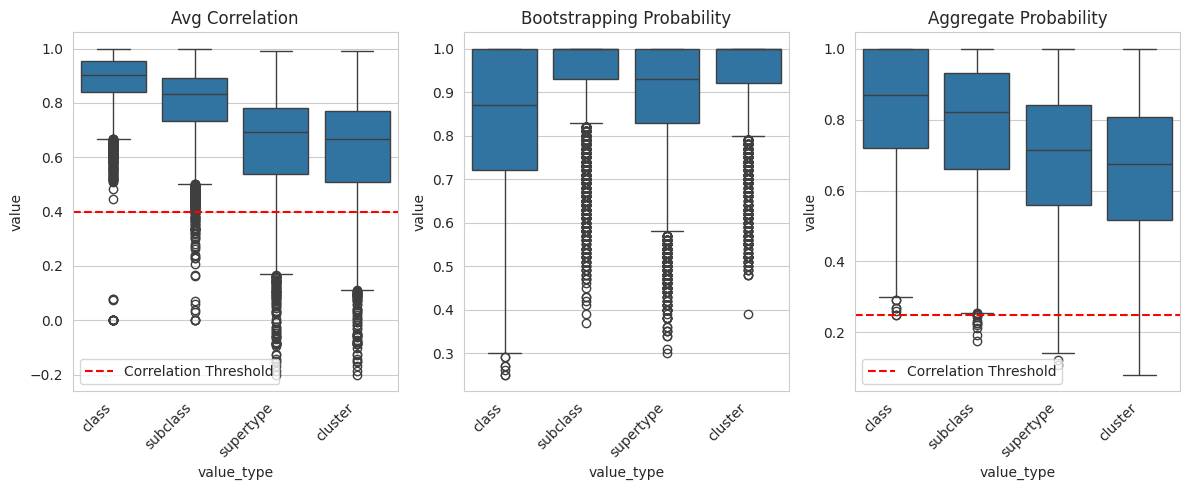

In [14]:
#################################
# Name for plot
plot_name = 'mapping_quality'
#################################
sns.set_style('whitegrid')
fig = taxonomy_mapper.plot_mapping_quality(hcr_data, 
                            avg_corr_thresh, 
                            agg_prob_thresh)
taxonomy_mapper.save_plot(fig, plots_output_path, plot_name, save_plots, overwrite_plots, save_format, save_plot_params, close_plots)

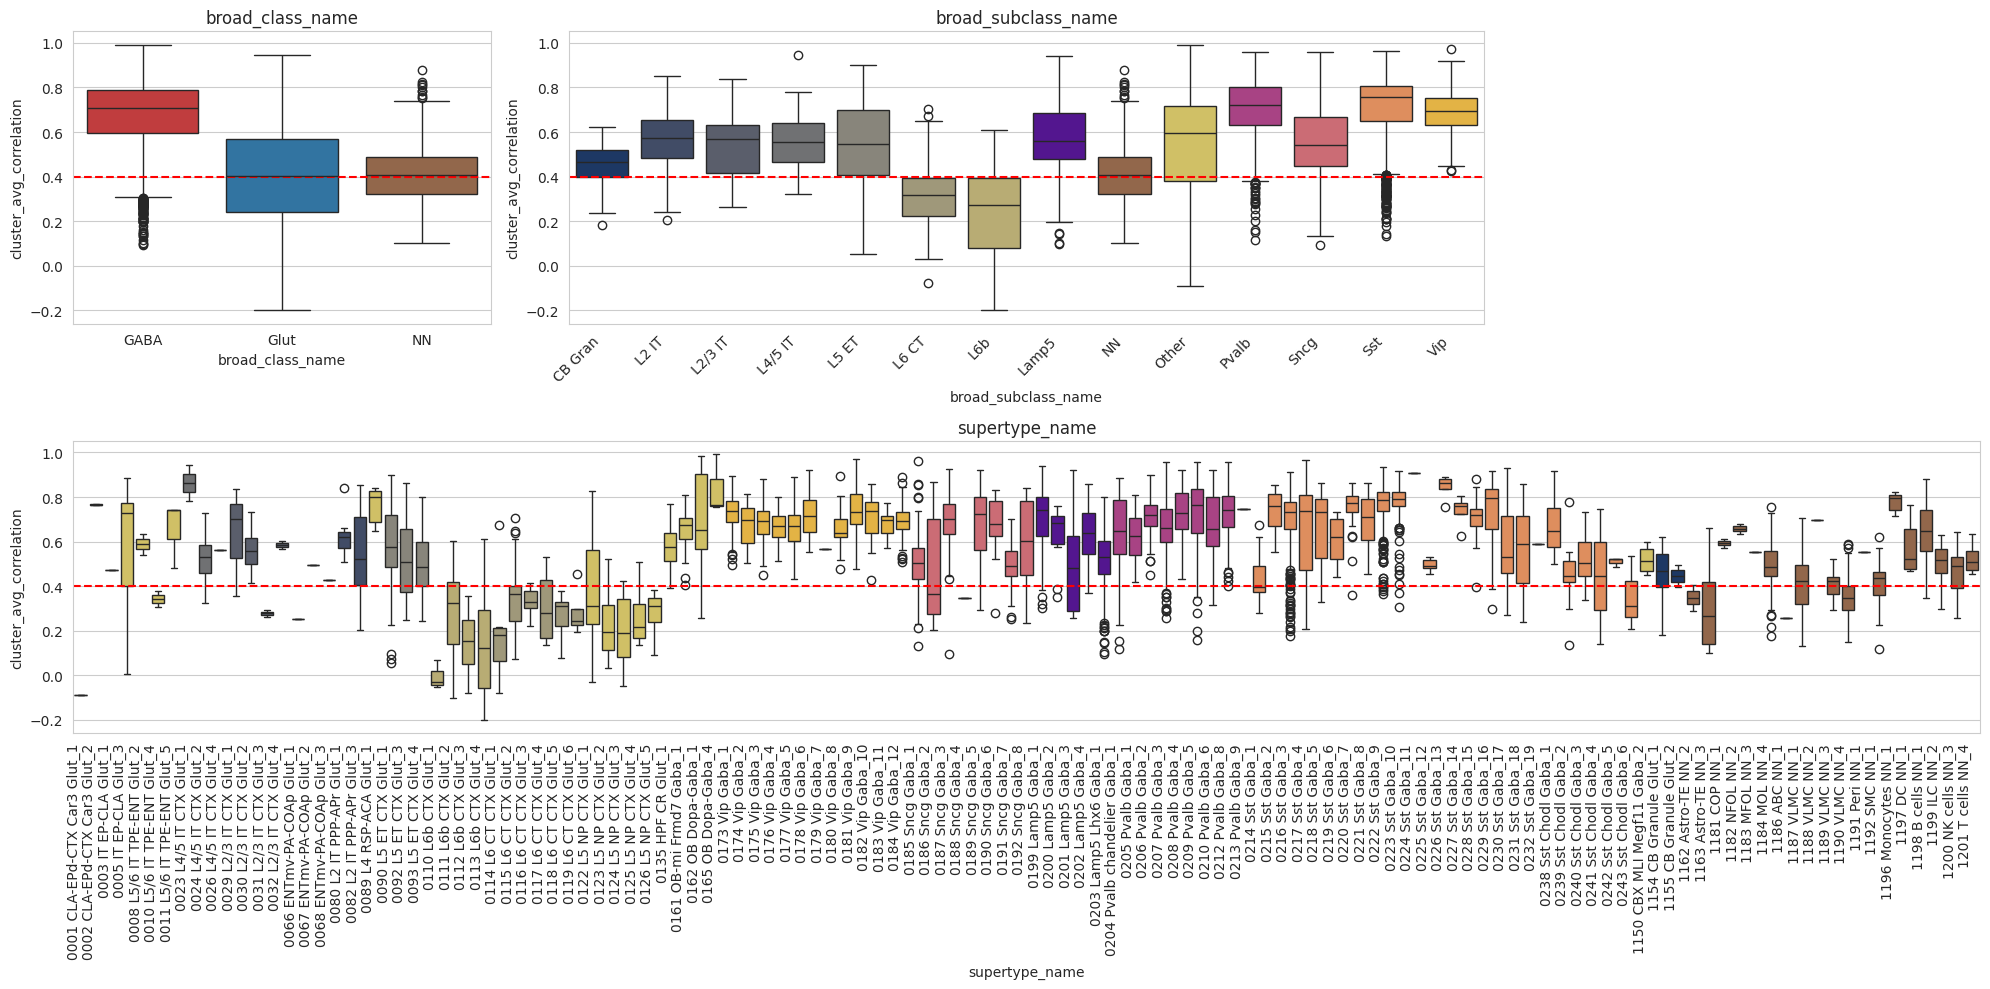

In [16]:
#################################
# Name for plot
plot_name = 'mapping_quality_by_types_avg_correlation'
#################################

fig = taxonomy_mapper.mapping_quality_boxplots(hcr_data.obs,
                        y='cluster_avg_correlation',
                        colormap=joined_colormap,
                        threshold_val=avg_corr_thresh)       

taxonomy_mapper.save_plot(fig, plots_output_path, plot_name, save_plots, overwrite_plots, save_format, save_plot_params, close_plots)

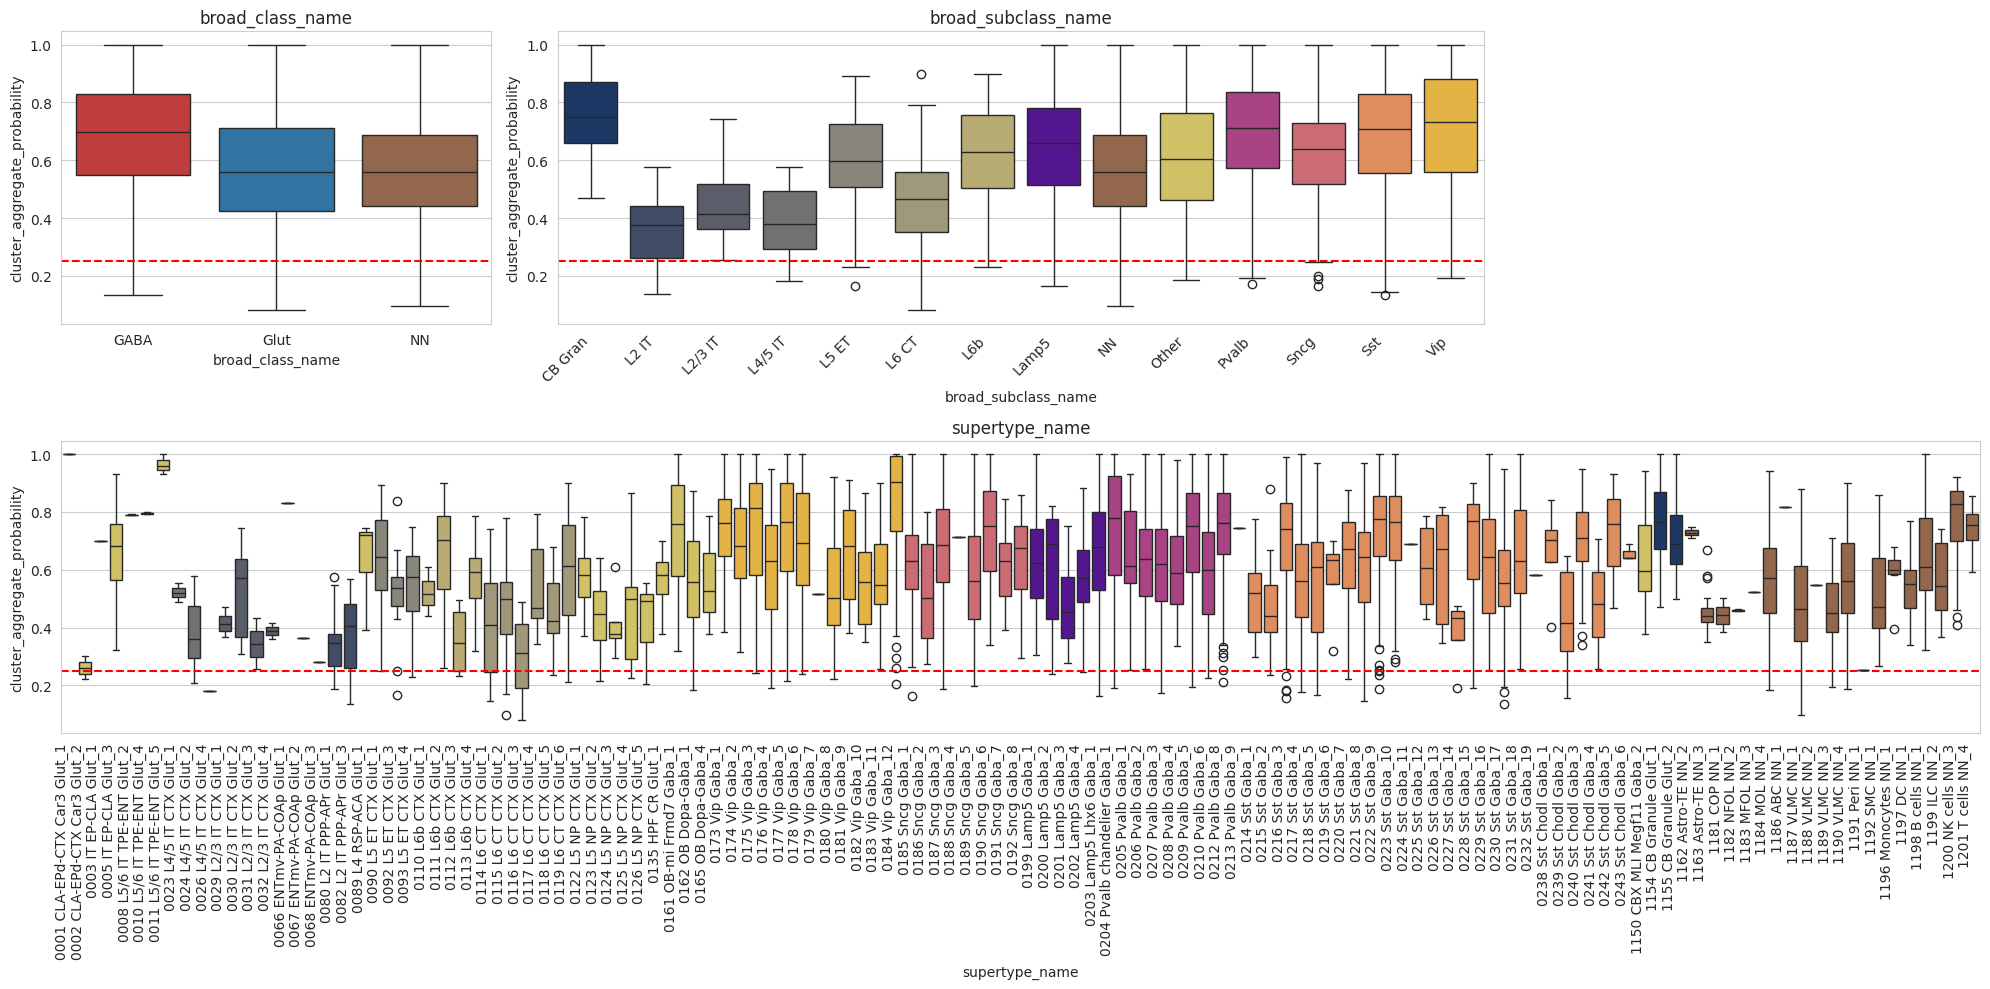

In [17]:
#################################
# Name for plot
plot_name = 'mapping_quality_by_type_aggregate_probability'
#################################

if np.all(hcr_data.obs.filter(regex='aggregate_probability$')==1):
    print("\nAll aggregate probabilities are 1, skipping aggregate probability boxplots.")
else:
    fig = taxonomy_mapper.mapping_quality_boxplots(hcr_data.obs,
                            y='cluster_aggregate_probability',
                            colormap=joined_colormap,
                            threshold_val=agg_prob_thresh)       

    taxonomy_mapper.save_plot(fig, plots_output_path, plot_name, save_plots, overwrite_plots, save_format, save_plot_params, close_plots)

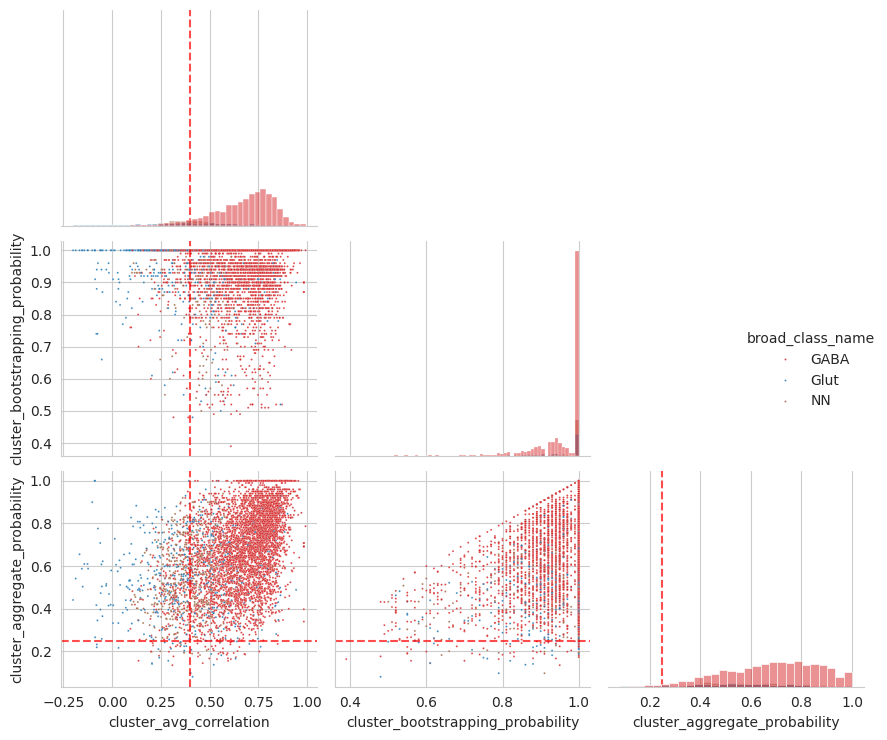

In [19]:
#################################
# Name for plot
plot_name = 'mapping_quality_params_pairplot'
#################################

if np.all(hcr_data.obs.filter(regex='aggregate_probability$')==1):
    print("\nAll aggregate probabilities are 1, skipping mapping quality pairplot.")
else:
    fig = taxonomy_mapper.mapping_quality_pairplot(
        plot_data=hcr_data.obs, 
        hierarchy_level='cluster', 
        color_col='broad_class_name', 
        joined_colormap=joined_colormap,
        avg_corr_thresh=avg_corr_thresh,
        agg_prob_thresh=agg_prob_thresh
    )
    taxonomy_mapper.save_plot(fig, plots_output_path, plot_name, save_plots, overwrite_plots, save_format, save_plot_params, close_plots)

## Filter cells based on mapping quality thresholds

In [20]:
# Bad mapping by type
bad_mapped_cells_counts = all_hcr_cells.loc[all_hcr_cells['cluster_avg_correlation'] < avg_corr_thresh].groupby(['class_name','subclass_name','supertype_name','cluster_name']).size().reset_index(name='count')

# Filter out from data
hcr_data = hcr_data[hcr_data.obs['cluster_avg_correlation'] >= avg_corr_thresh]

print(f"Total cells: {total_cells}")
print(f"Cells with cluster average correlation below {avg_corr_thresh}: {all_hcr_cells.shape[0] - hcr_data.shape[0]} ({(all_hcr_cells.shape[0] - hcr_data.shape[0])/total_cells*100:.2f}%)")
print(f"Cells remaining: {hcr_data.shape[0]} ({hcr_data.shape[0]/total_cells*100:.2f}%)")
print(f"\nPoor quality mapping by type:")
bad_mapped_cells_counts[bad_mapped_cells_counts['count'] > 0].sort_values(by='count', ascending=False)

/tmp/ipykernel_21685/807690456.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bad_mapped_cells_counts = all_hcr_cells.loc[all_hcr_cells['cluster_avg_correlation'] < avg_corr_thresh].groupby(['class_name','subclass_name','supertype_name','cluster_name']).size().reset_index(name='count')


Total cells: 5598
Cells with cluster average correlation below 0.4: 769 (13.74%)
Cells remaining: 4829 (86.26%)

Poor quality mapping by type:


,class_name,subclass_name,supertype_name,cluster_name,count
13877068,33 Vascular,330 VLMC NN,1190 VLMC NN_4,5303 VLMC NN_4,203
1487684,02 NP-CT-L6b Glut,029 L6b CTX Glut,0111 L6b CTX Glut_2,0428 L6b CTX Glut_2,51
1488248,02 NP-CT-L6b Glut,029 L6b CTX Glut,0113 L6b CTX Glut_4,0435 L6b CTX Glut_4,34
1523252,02 NP-CT-L6b Glut,030 L6 CT CTX Glut,0115 L6 CT CTX Glut_2,0441 L6 CT CTX Glut_2,24
6493357,07 CTX-MGE GABA,050 Lamp5 Lhx6 Gaba,0203 Lamp5 Lhx6 Gaba_1,0727 Lamp5 Lhx6 Gaba_1,24
...,...,...,...,...,...
12635819,31 OPC-Oligo,327 Oligo NN,1184 MOL NN_4,5285 MOL NN_4,1
13841503,33 Vascular,329 ABC NN,1186 ABC NN_1,5293 ABC NN_1,1
12635822,31 OPC-Oligo,327 Oligo NN,1184 MOL NN_4,5288 MOL NN_4,1
15221636,34 Immune,338 Lymphoid NN,1198 B cells NN_1,5319 B cells NN_1,1


## Gene Expression

In [21]:
gene_order = ['GFP','Gad2','Sst','Pvalb','Vip','Cck','Npy']
gene_order = gene_order + sorted(list(set(hcr_data.var_names) - set(gene_order)))

# Filter clusters where only one cell mapped
cluster_counts = hcr_data.obs['cluster_name'].value_counts()
hcr_data = hcr_data[hcr_data.obs['cluster_name'].isin(cluster_counts[cluster_counts > 1].index)]

### UMAP

In [24]:
%matplotlib inline

In [25]:
#################################
# Name for plot
plot_name = '_types_counts'
#################################
if plot_slow_plots:
    sc.pp.calculate_qc_metrics(hcr_data, percent_top=None, inplace=True)
    if 'X_umap' not in hcr_data.obsm:
        sc.pp.neighbors(hcr_data)
        sc.tl.umap(hcr_data)
    sc.pl.umap(
        hcr_data,
        color=["broad_class_name", "broad_subclass_name", "cluster_avg_correlation", "log1p_total_counts", "n_genes_by_counts"],
        palette=joined_colormap,
        wspace=0.25,
        ncols=2,
        save=f'{plot_name}.{save_format}' if save_plots else None,
    )

plt.show()

## Heatmap of expression across subclasses (simple subclass categories)
### 

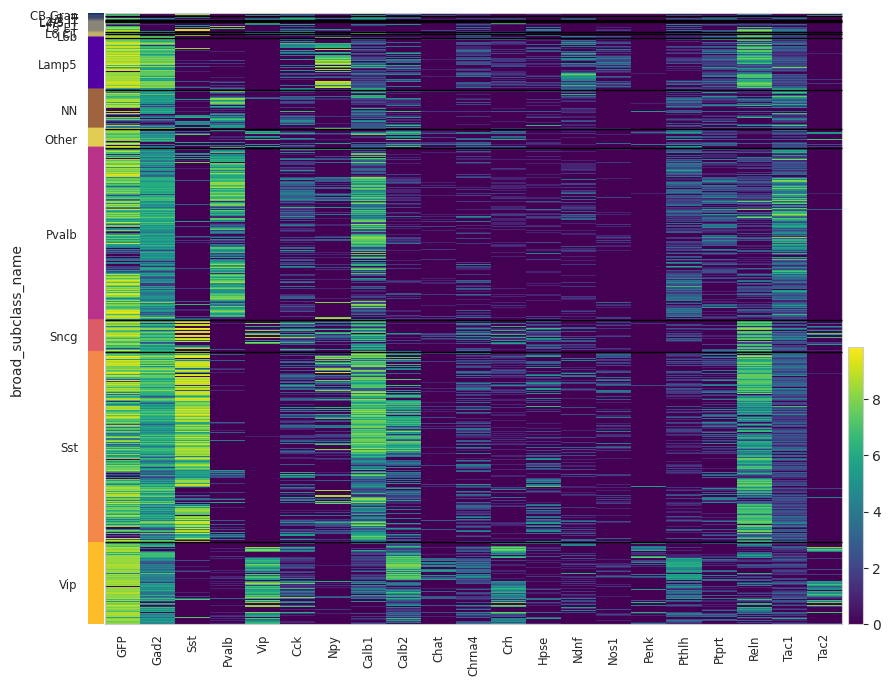

In [26]:
#################################
# Name for plot
plot_name = '_broad_subclass_name'
#################################

sc.pl.heatmap(
    hcr_data,
    var_names=gene_order,
    groupby='broad_subclass_name',
    layer='log1p',
    swap_axes=False,
    figsize=(10, 8),
    cmap='viridis',
    save=f'{plot_name}.{save_format}' if save_plots else None,
)

### trackplot of expression across supertypes

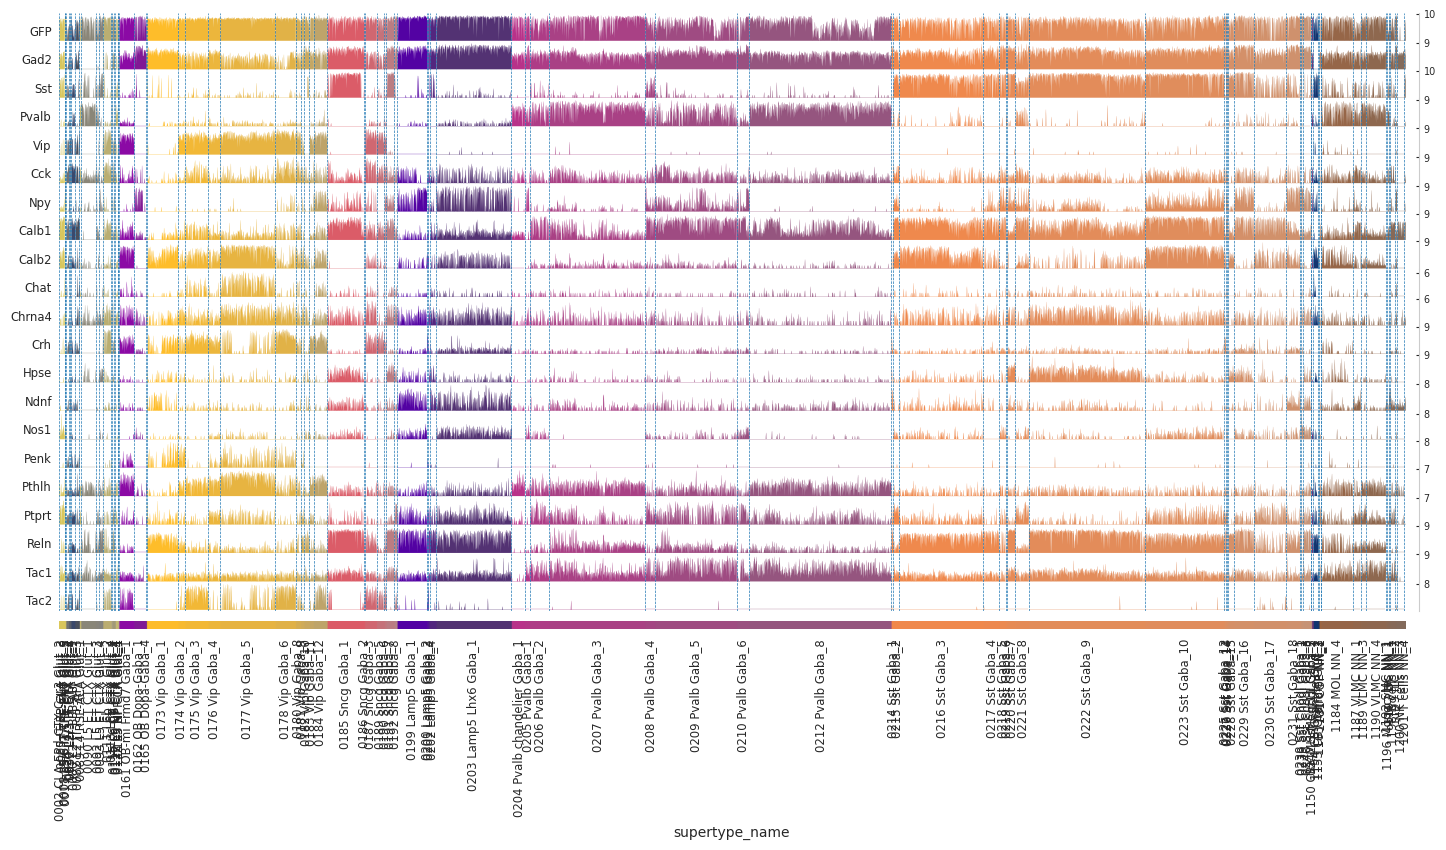

In [27]:
#################################
# Name for plot
plot_name = '_supertype_name'
#################################

sc.pl.tracksplot(
        hcr_data, 
        var_names=gene_order, 
        groupby='supertype_name', 
        layer='log1p',
        figsize=(18, 8),
        save=f'{plot_name}.{save_format}' if save_plots else None,
    )

### Gene expression by class & supertype assignment 
(these take the longest to plot & have to manually save)

In [ ]:
#################################
# Name for plot
plot_name = 'stacked_violin_subclass_name'
#################################

if plot_slow_plots:b
    fig = sc.pl.stacked_violin(
        hcr_data,
        var_names=gene_order,
        groupby='subclass_name',
        layer='log1p',
        swap_axes=False,
        title='Subclasses',
        return_fig=True,
        show=False,
    )
    fig=fig.add_totals().style(ylim=(0,5))
    save_plot(fig, plots_output_path, plot_name, save_plots, overwrite_plots, save_format, save_plot_params)

### Gene expression by class & subclass assignment

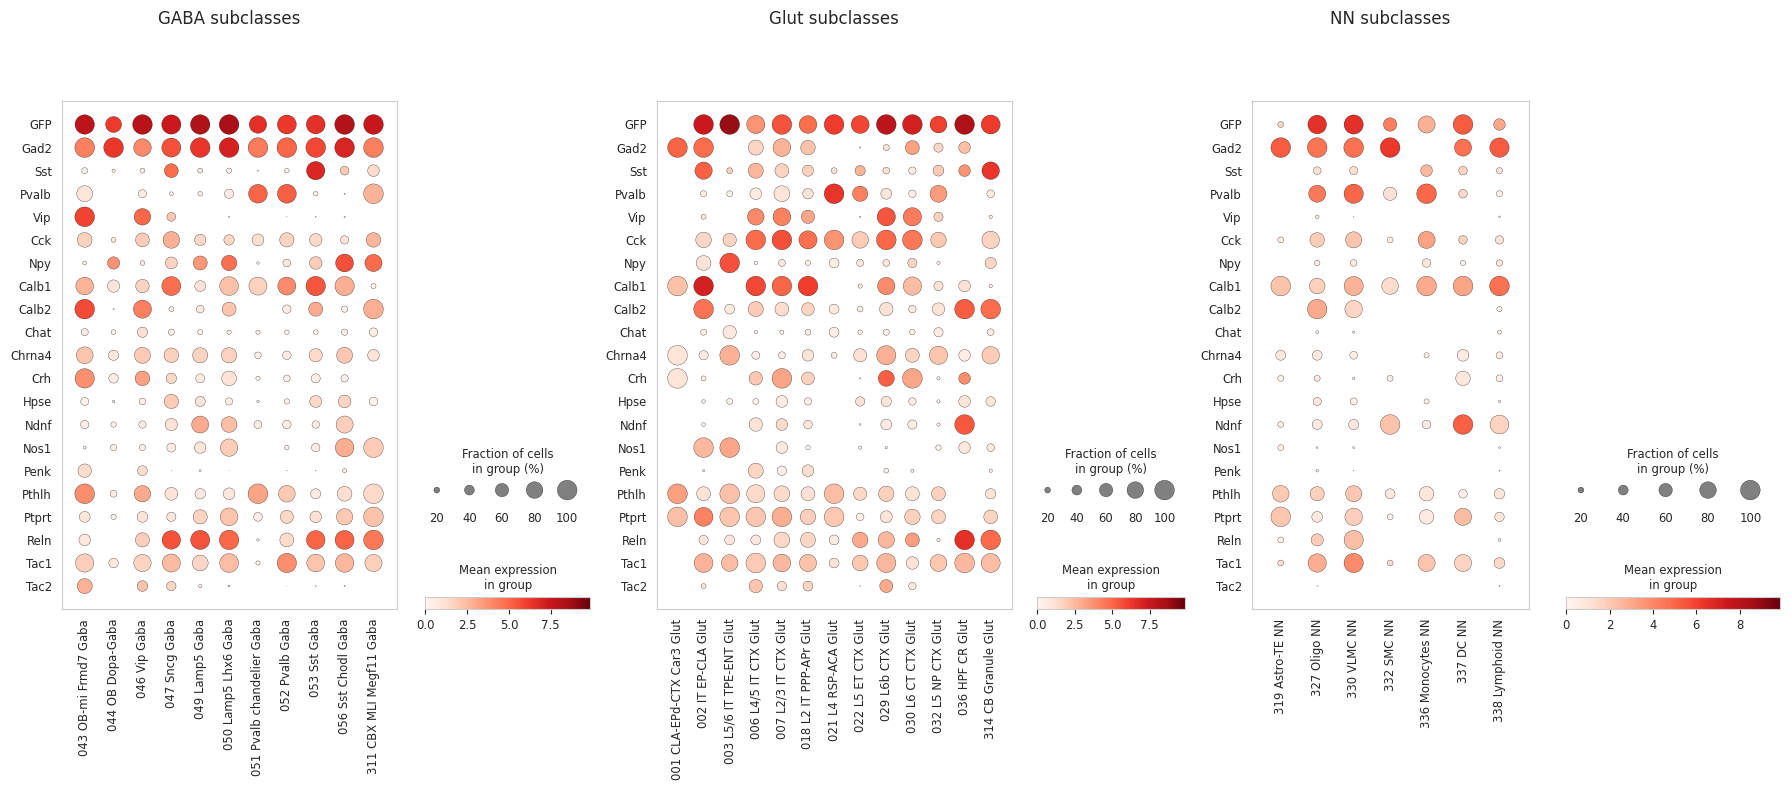

In [29]:
#################################
# Name for plot
plot_name = 'dotplot_broad_class_name'
#################################

fig, axes = plt.subplots(1,3, figsize=(18, 8))
vmin,vmax = 0, np.max(hcr_data.layers['log1p'])

for class_n in ['GABA', 'Glut', 'NN']:
    sc.pl.dotplot(
            hcr_data[hcr_data.obs['broad_class_name'] == class_n],
            var_names=gene_order,
            groupby='subclass_name',
            layer='log1p',
            show=False,
            swap_axes=True,
            num_categories=hcr_data.obs[hcr_data.obs['broad_class_name'] == class_n]['subclass_name'].nunique(),
            ax=axes[['GABA', 'Glut', 'NN'].index(class_n)],
            title=f'{class_n} subclasses',
            vmin=vmin,
            vmax=vmax
        )
plt.tight_layout()

taxonomy_mapper.save_plot(fig, plots_output_path, plot_name, save_plots, overwrite_plots, save_format, save_plot_params)

## Gene expression by class x supertype

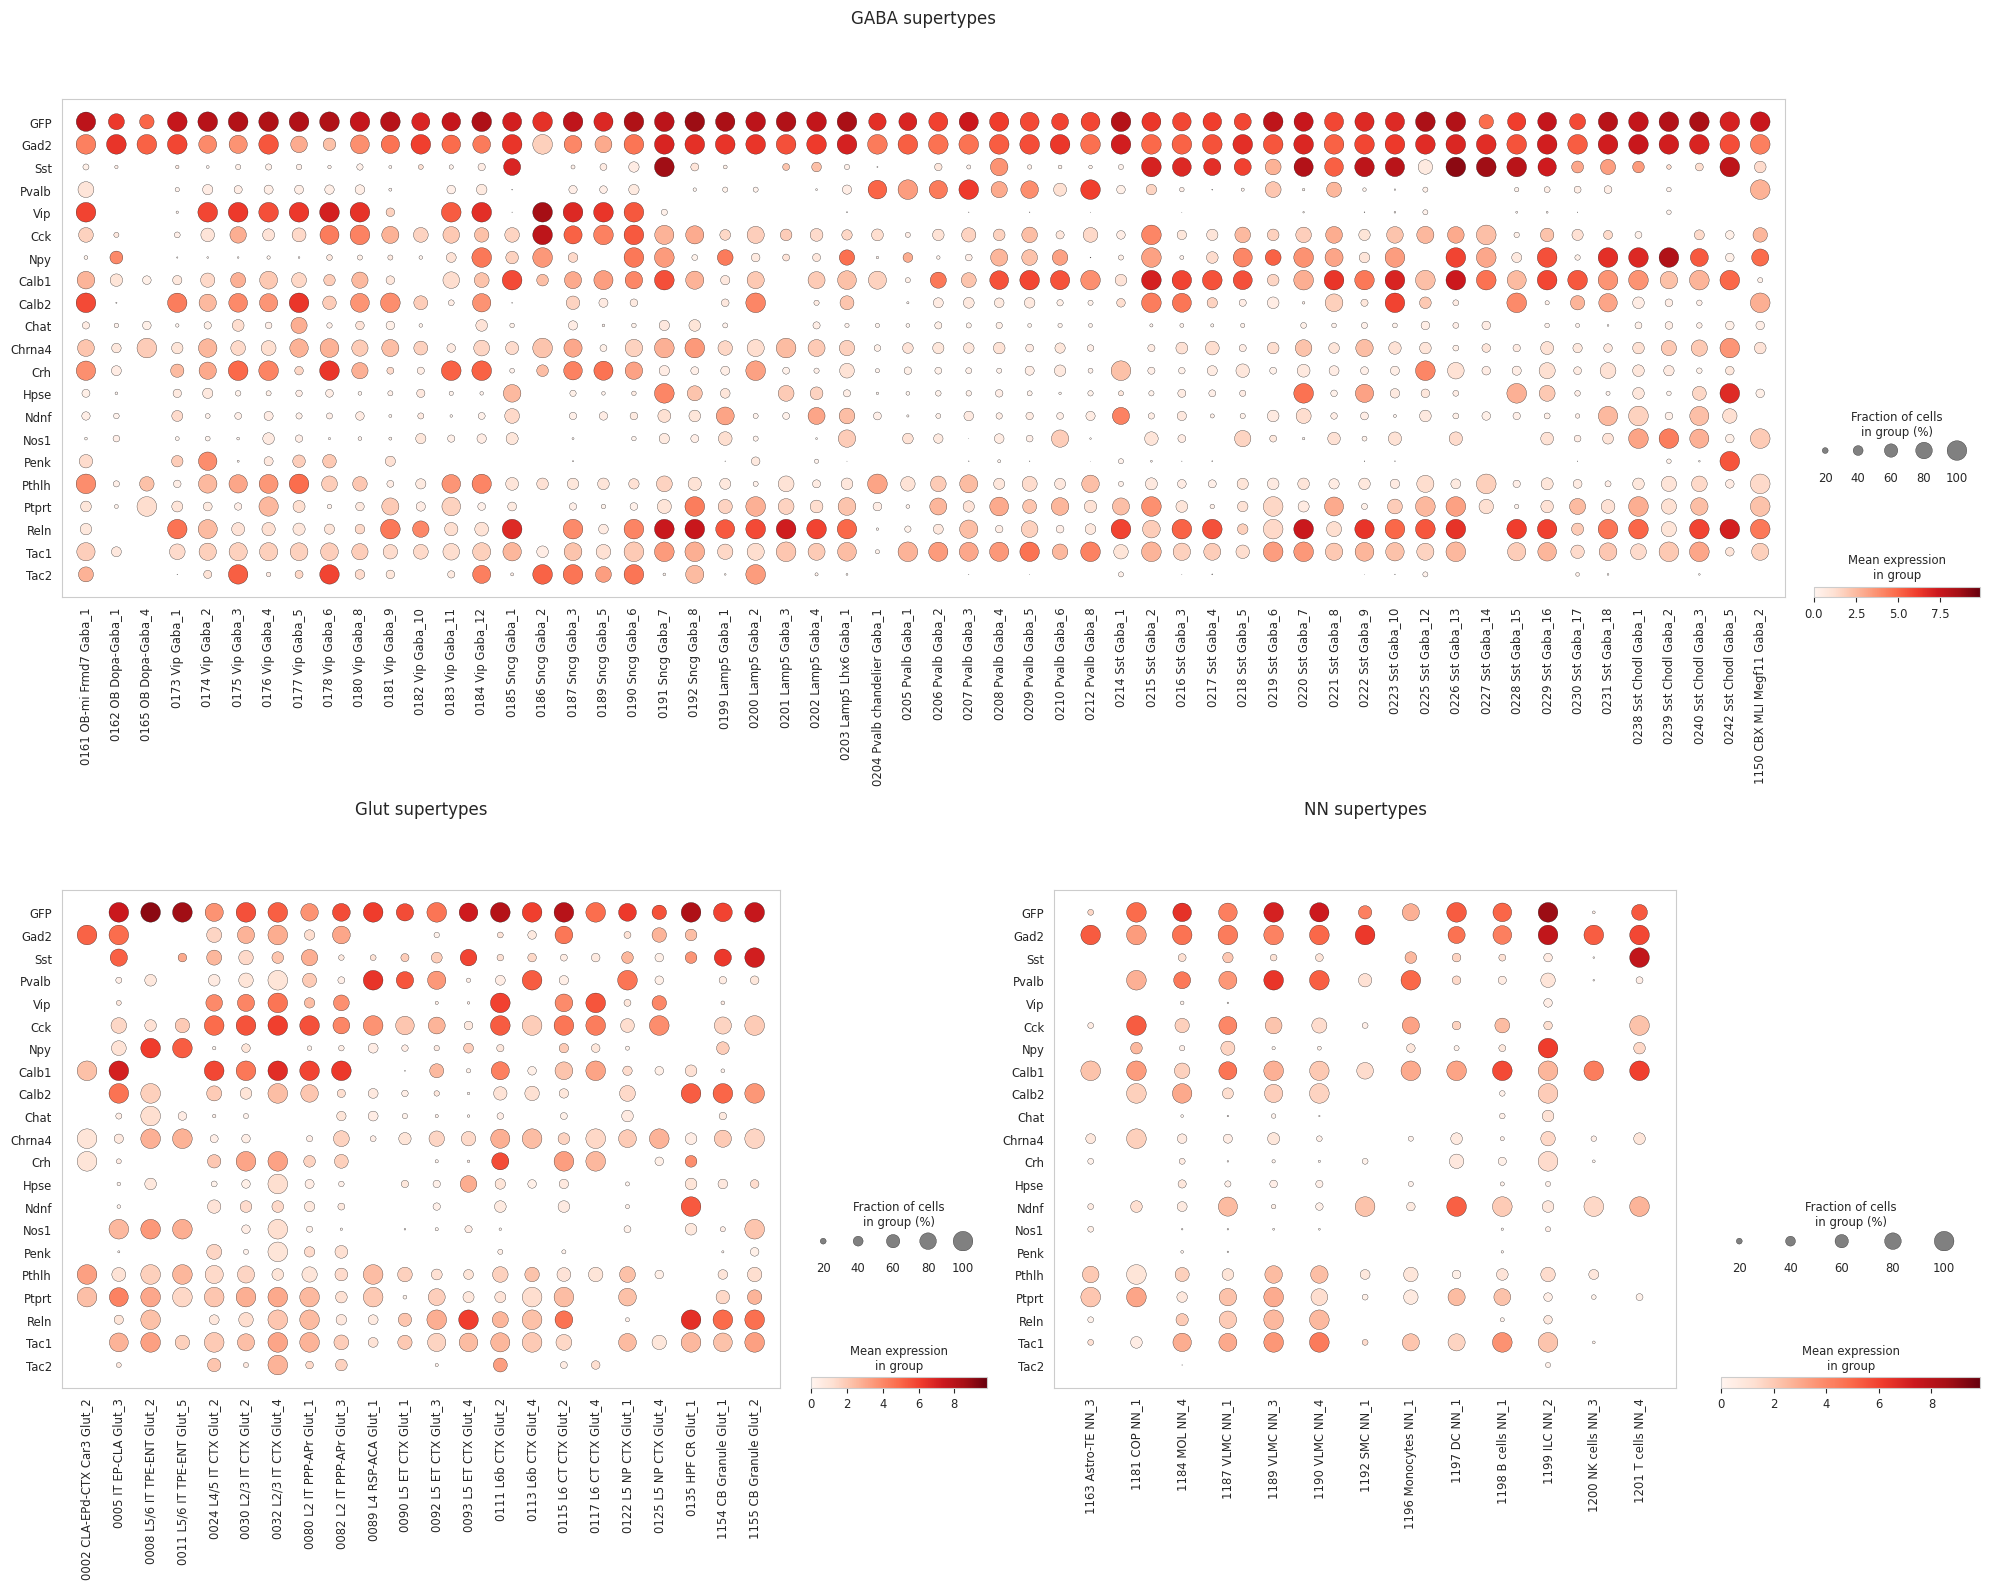

In [30]:
#################################
# Name for plot
plot_name = 'dotplot_supertype_name'
#################################

fig, axes = plt.subplots(2, 2, figsize=(20, 16))
vmin, vmax = 0, np.max(hcr_data.layers['log1p'])

gs = fig.add_gridspec(2, 2)
ax_gaba = fig.add_subplot(gs[0, :]) 

sc.pl.dotplot(
    hcr_data[hcr_data.obs['broad_class_name'] == 'GABA'],
    var_names=gene_order,
    groupby='supertype_name',
    layer='log1p',
    show=False,
    swap_axes=True,
    num_categories=hcr_data[hcr_data.obs['broad_class_name'] == 'GABA'].obs['supertype_name'].nunique(),
    ax=ax_gaba,
    title='GABA supertypes',
    vmin=vmin,
    vmax=vmax
)

for i, class_n in enumerate(['Glut', 'NN']):
    sc.pl.dotplot(
        hcr_data[hcr_data.obs['broad_class_name'] == class_n],
        var_names=gene_order,
        groupby='supertype_name',
        layer='log1p',
        show=False,
        swap_axes=True,
        num_categories=hcr_data[hcr_data.obs['broad_class_name'] == class_n].obs['supertype_name'].nunique(),
        ax=axes[1, i],
        title=f'{class_n} supertypes',
        vmin=vmin,
        vmax=vmax
    )

axes[0, 0].remove()
axes[0, 1].remove()
plt.tight_layout()

taxonomy_mapper.save_plot(fig, plots_output_path, plot_name, save_plots, overwrite_plots, save_format, save_plot_params)

## Type assignments 

In [32]:
# Number of cells assigned to each class (broad class) and subclass
counts = taxonomy_mapper.get_types_breakdown(hcr_data, 'broad_class_name', 'broad_subclass_name')
counts

/code/taxonomy_mapper.py:346: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub_counts = adata.obs.groupby([col_name, sub_col_name]).size().sort_values(ascending=False)


,broad_class_name,broad_subclass_name,count
0,GABA,Lamp5,405
1,GABA,Other,104
2,GABA,Pvalb,1346
3,GABA,Sncg,248
4,GABA,Sst,1490
5,GABA,Vip,640
6,Glut,CB Gran,21
7,Glut,L2 IT,30
8,Glut,L2/3 IT,8
9,Glut,L4/5 IT,10


/code/taxonomy_mapper.py:346: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub_counts = adata.obs.groupby([col_name, sub_col_name]).size().sort_values(ascending=False)
/code/taxonomy_mapper.py:582: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts['proportion'] = counts.groupby(main_cat)['count'].transform(lambda x: x / x.sum())


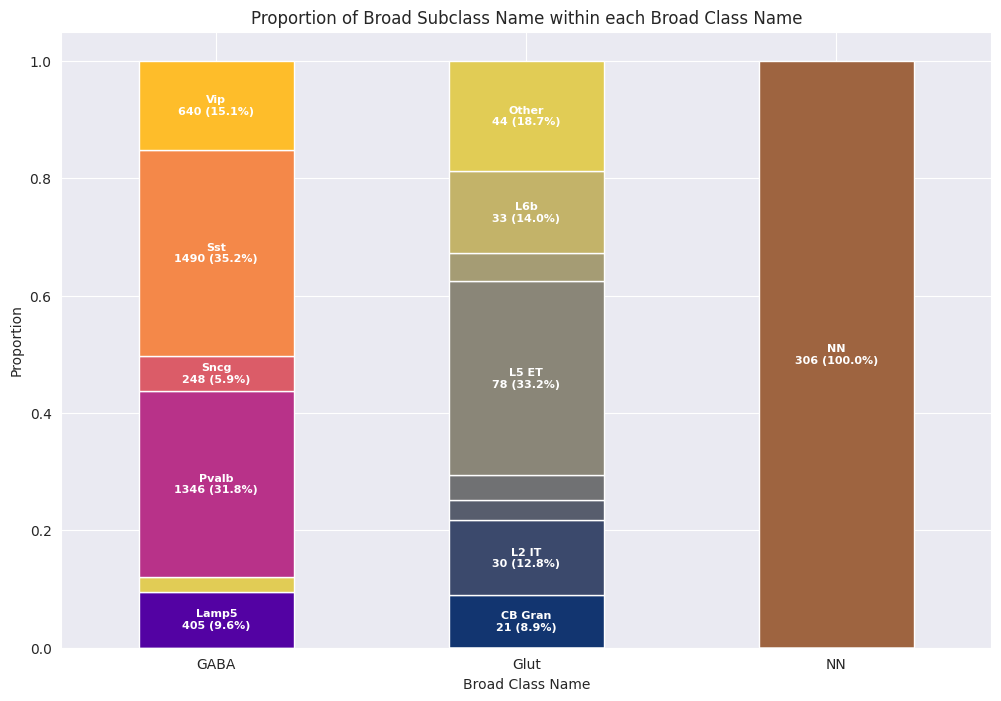

In [34]:
#################################
# Name for plot
plot_name = 'class_subclass_proportions'
#################################
sns.set_style('darkgrid')
fig, ax = plt.subplots(figsize=(12, 8))
taxonomy_mapper.plot_stacked_categories(hcr_data, 'broad_class_name', 'broad_subclass_name', joined_colormap, ax)

taxonomy_mapper.save_plot(fig, plots_output_path, plot_name, save_plots, overwrite_plots, save_format, save_plot_params)

/code/taxonomy_mapper.py:346: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub_counts = adata.obs.groupby([col_name, sub_col_name]).size().sort_values(ascending=False)
/code/taxonomy_mapper.py:582: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts['proportion'] = counts.groupby(main_cat)['count'].transform(lambda x: x / x.sum())
/code/taxonomy_mapper.py:346: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sub_counts = 

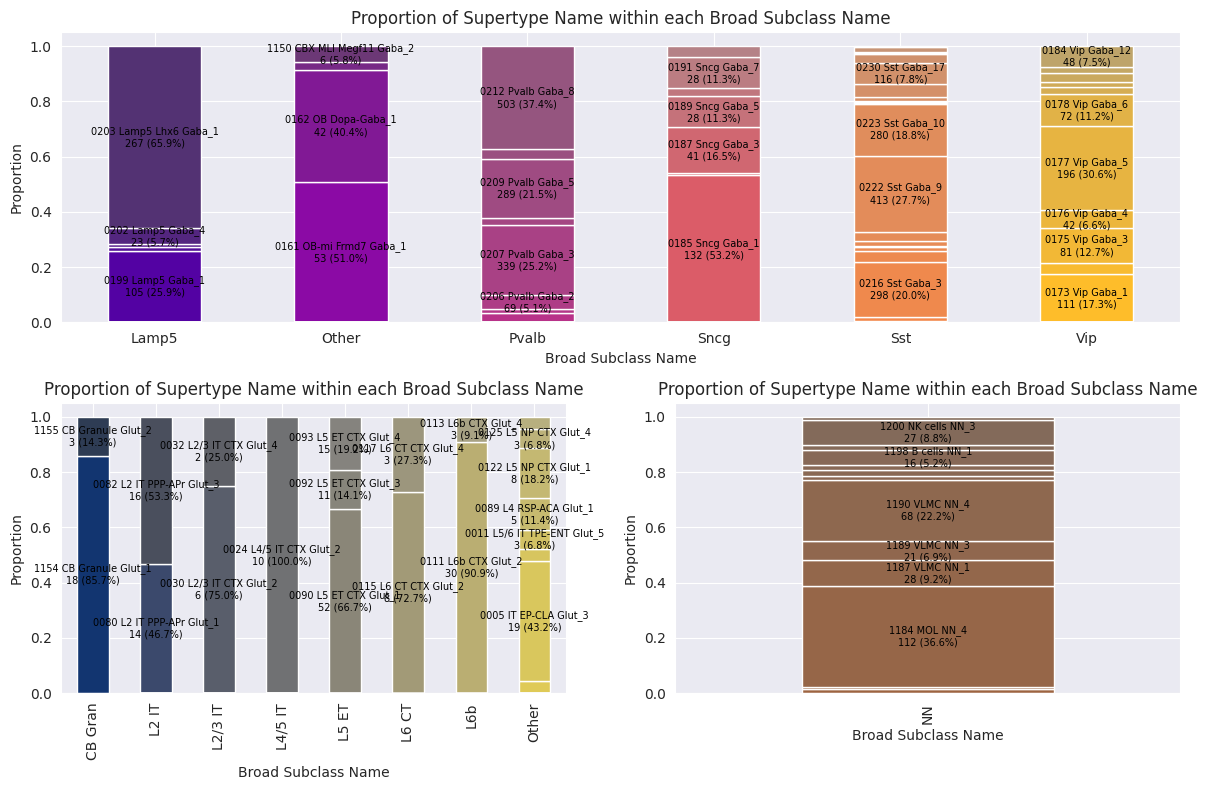

In [35]:
#################################
# Name for plot
plot_name = 'class_subclass_supertypes_proportions'
#################################

fig, axes = plt.subplots(2, 2, figsize=(20, 16))
gs = fig.add_gridspec(2, 2)
ax_gaba = fig.add_subplot(gs[0, :]) 
taxonomy_mapper.plot_stacked_categories(hcr_data[hcr_data.obs['broad_class_name']=='GABA'], 'broad_subclass_name', 'supertype_name', joined_colormap, ax_gaba, 
                            kwargs={'font_color': 'black', 'font_weight': 'normal', 'font_size': 7})
taxonomy_mapper.plot_stacked_categories(hcr_data[hcr_data.obs['broad_class_name']=='Glut'], 'broad_subclass_name', 'supertype_name', joined_colormap,  ax=axes[1, 0], 
                            kwargs={'font_color': 'black', 'font_weight': 'normal', 'font_size': 7})
taxonomy_mapper.plot_stacked_categories(hcr_data[hcr_data.obs['broad_class_name']=='NN'], 'broad_subclass_name', 'supertype_name', joined_colormap, ax=axes[1, 1], 
                            kwargs={'font_color': 'black', 'font_weight': 'normal', 'font_size': 7})
axes[0, 0].remove()
axes[0, 1].remove()
plt.tight_layout()

taxonomy_mapper.save_plot(fig, plots_output_path, plot_name, save_plots, overwrite_plots, save_format, save_plot_params)   

### HCR assigned cluster labels to assigned supertype names

In [36]:
#################################
# Name for plot
plot_name = 'manual_clusters_supertypes'
#################################

# Cluster ID labels
if 'hcr_cluster_label' not in hcr_data.obs.columns:
    cluster_labels_csv = '/root/capsule/data/HCR_767018_Oregano_251104/767018_Oregano_inhibitory_clustered_cellxgene_with_cluster_labels.csv'
    cluster_labels_df = pd.read_csv(cluster_labels_csv)
    cluster_labels_df.rename(columns={'cluster_id': 'hcr_cluster_id', 'cluster_label': 'hcr_cluster_label'}, inplace=True)
    cluster_labels_df.set_index('cell_id', inplace=True)
    hcr_data.obs = hcr_data.obs.merge(cluster_labels_df['hcr_cluster_label'], on='cell_id', how='left')

fig = taxonomy_mapper.create_sankey_diagram(
    hcr_data, 
    ['hcr_cluster_label','supertype_name'], 
    colormap=joined_colormap, 
    sort_columns={'supertype_name': 'normal'},
    title="Cluster Label -> Supertype",
    height=1000, width=700)
fig.show()
fig.write_html(f"{plots_output_path}/{plot_name}.html")

/opt/conda/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
